# Model Training

## Objective

Train a baseline Logistic Regression model using a Scikit-Learn Pipeline.

The pipeline will automatically:

- preprocess raw customer data
- encode categorical variables
- scale numerical variables
- train the model



In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_auc_score,
    RocCurveDisplay
)

import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../data/processed/telco_cleaned.csv")

In [3]:
X = df.drop(columns=["Churn", "Churn_Binary"])

y = df["Churn_Binary"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
categorical_features = X.select_dtypes(include=["object", "string"]).columns

numerical_features = X.select_dtypes(exclude=["object", "string"]).columns

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

C:\Users\SARWAR\AppData\Local\Temp\ipykernel_27828\2654666752.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include="object").columns


In [ ]:
pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(
                random_state=42,
                max_iter=1000
            )
        )
    ]
)

In [ ]:
pipeline.fit(X_train, y_train)

In [ ]:
y_pred = pipeline.predict(X_test)

y_prob = pipeline.predict_proba(X_test)[:,1]

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.8038


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



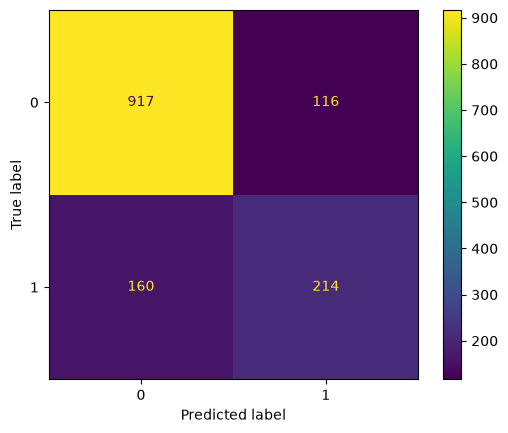

In [11]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.show()

In [12]:
y_prob = model.predict_proba(X_test)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.8357193885210513


In [ ]:
joblib.dump(
    pipeline,
    "../models/customer_churn_pipeline.pkl"
)

['../models/logistic_regression.pkl']

# Model Training Summary

## Model

- Logistic Regression

## Preprocessing

- Standard Scaling
- One-Hot Encoding

## Evaluation Metrics

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Confusion Matrix

## Outcome

The baseline Logistic Regression model was successfully trained and saved for future inference and comparison with more advanced models.